<a href="https://colab.research.google.com/github/QueenMary100/PharmStockAI/blob/main/PharmacyColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Pharm-stock AI

###This is a sale projection system using industry data to model and come up with an interactive dashboard

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
#create path variable
path = "/content/drive/MyDrive/ENGAGEMary_Diana/Engage_Pharm_Data"

In [5]:
#import the necessary libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [6]:
#load the csv file
df = pd.read_csv(os.path.join(path, "pharm_stock_dataset_v2_15_Sep_26.csv"))

In [7]:
#EDA Analysis
df.shape

(57317, 14)

In [8]:
#show columns
df.columns

Index(['report_year', 'report_month', 'period_start', 'item', 'location',
       'op_stock', 'sales_qty', 'sales_value', 'pch_qty', 'pch_value',
       'adj_stock', 'transf_stock', 'cls_stock', 'source_file'],
      dtype='object')

In [9]:
#show missing data
df.isnull().sum()

,0
report_year,0
report_month,0
period_start,0
item,0
location,0
op_stock,0
sales_qty,0
sales_value,0
pch_qty,0
pch_value,0


In [10]:
df.head()

,report_year,report_month,period_start,item,location,op_stock,sales_qty,sales_value,pch_qty,pch_value,adj_stock,transf_stock,cls_stock,source_file
0,2023,1,1/1/2023,(TAMEDOL) PARACETAMOL SUSP 60ML,PHARMACY,8,12.00,330.0,80.0,1600.0,0.0,0.0,76,jan_2023.pdf
1,2023,1,1/1/2023,ABZ SUSPENSION 400MG/10ML,PHARMACY,613,33.00,1630.0,50.0,1600.0,0.0,0.0,630,jan_2023.pdf
2,2023,1,1/1/2023,ABZ TABS 400MG 1S,PHARMACY,960,28.00,875.0,0.0,0.0,0.0,0.0,932,jan_2023.pdf
3,2023,1,1/1/2023,ACEPAR MR TABS 10`S,PHARMACY,124,0.60,192.0,0.0,0.0,0.0,0.0,118,jan_2023.pdf
4,2023,1,1/1/2023,ACETAL MR(ACECLOFENAC)100`S,PHARMACY,500,0.83,508.0,2.0,952.0,0.0,0.0,617,jan_2023.pdf


In [11]:
df.describe()

,report_year,report_month,op_stock,sales_qty,sales_value,pch_qty,pch_value,adj_stock,transf_stock,cls_stock
count,57317.000000,57317.000000,57317.000000,57317.000000,57317.000000,57317.000000,57317.000000,57317.000000,57317.000000,57317.000000
mean,2024.592145,6.326151,964.274910,3.660106,1486.285616,3.167797,882.721347,0.557159,-0.008603,979.224453
std,1.151639,3.359575,9993.716476,9.608177,2407.694321,19.454940,3008.404502,8.384529,0.625515,10236.803901
min,2023.000000,1.000000,-10.000000,0.000000,2.000000,0.000000,-19401.000000,0.000000,-100.240000,-10.000000
25%,2023.000000,3.000000,8.000000,1.000000,280.000000,0.000000,0.000000,0.000000,0.000000,7.000000
50%,2025.000000,6.000000,40.000000,1.330000,700.000000,0.000000,0.000000,0.000000,0.000000,39.000000
75%,2026.000000,9.000000,189.000000,3.010000,1680.000000,2.000000,1000.000000,0.000000,0.000000,188.000000
max,2026.000000,12.000000,499985.000000,1059.000000,78575.000000,3500.000000,511000.000000,1280.000000,7.000000,499985.000000


In [12]:
import numpy as np

# Identify columns that should logically not be negative
numeric_cols = ['op_stock', 'sales_qty', 'sales_value', 'pch_qty', 'pch_value', 'adj_stock', 'cls_stock']

# Count negative values before cleaning
neg_counts = (df[numeric_cols] < 0).sum()
print("Negative value counts per column before cleaning:")
print(neg_counts[neg_counts > 0])

# Clean the data: Replace negative values with 0
# We use clip(lower=0) to ensure all values are at least 0
df[numeric_cols] = df[numeric_cols].clip(lower=0)

print("\nData cleaned: All negative values in stock and sales columns have been clipped to 0.")
print("New minimum values:")
print(df[numeric_cols].min())

Negative value counts per column before cleaning:
op_stock     7
pch_value    2
cls_stock    6
dtype: int64

Data cleaned: All negative values in stock and sales columns have been clipped to 0.
New minimum values:
op_stock       0.0
sales_qty      0.0
sales_value    2.0
pch_qty        0.0
pch_value      0.0
adj_stock      0.0
cls_stock      0.0
dtype: float64


**Reasoning**:
The first step is to convert the 'period_start' column to a datetime object, which is crucial for any time-series analysis and aggregation.



In [13]:
df['period_start'] = pd.to_datetime(df['period_start'])
print("Converted 'period_start' to datetime.")

Converted 'period_start' to datetime.


**Reasoning**:
To analyze monthly trends, I will aggregate the data by 'period_start' (which is already a datetime object) and sum the specified sales and stock columns, then visualize these trends using line plots.



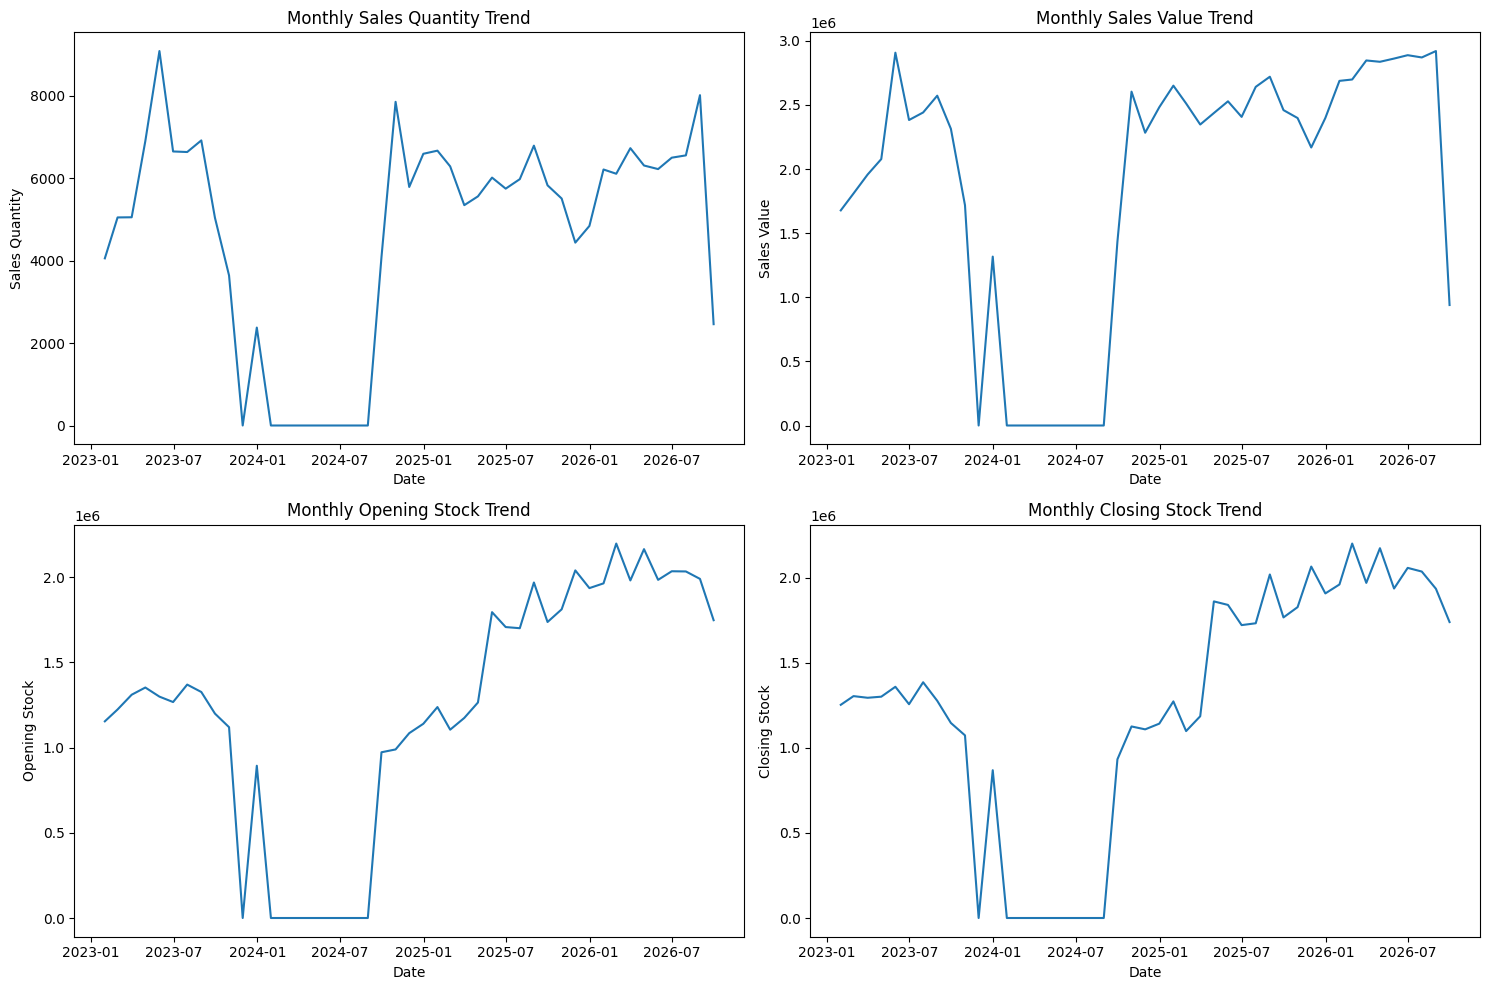

Monthly sales and stock trends visualized.


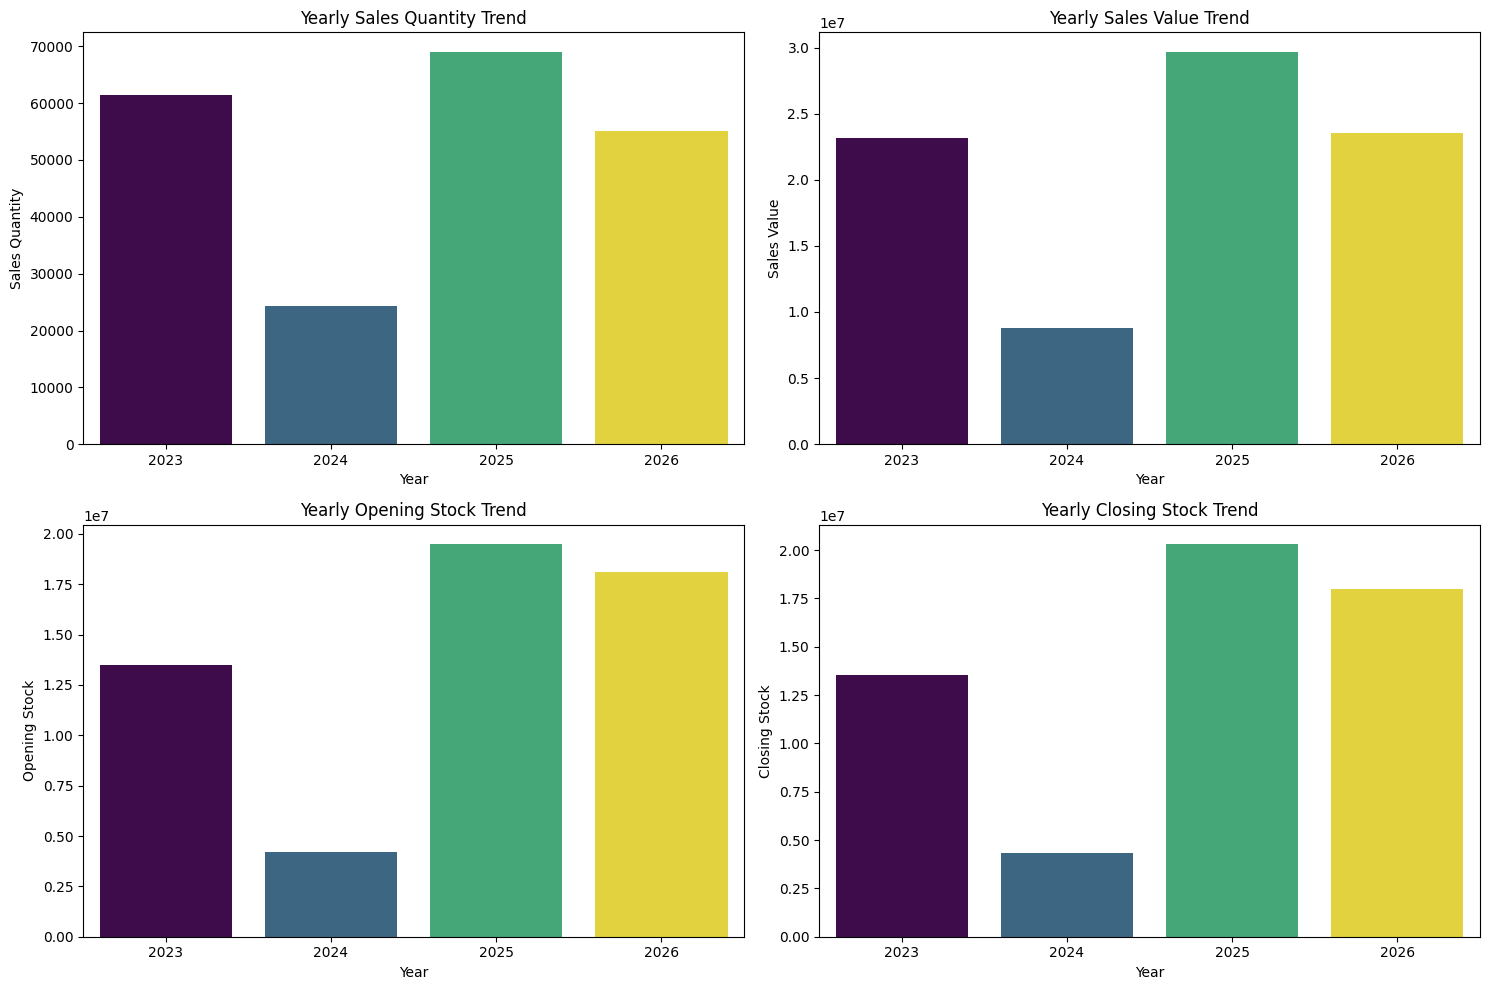

Yearly sales and stock trends visualized.


In [14]:
monthly_df = df.set_index('period_start').resample('ME').agg({
    'sales_qty': 'sum',
    'sales_value': 'sum',
    'op_stock': 'sum',
    'cls_stock': 'sum'
}).reset_index()

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.lineplot(x='period_start', y='sales_qty', data=monthly_df)
plt.title('Monthly Sales Quantity Trend')
plt.xlabel('Date')
plt.ylabel('Sales Quantity')

plt.subplot(2, 2, 2)
sns.lineplot(x='period_start', y='sales_value', data=monthly_df)
plt.title('Monthly Sales Value Trend')
plt.xlabel('Date')
plt.ylabel('Sales Value')

plt.subplot(2, 2, 3)
sns.lineplot(x='period_start', y='op_stock', data=monthly_df)
plt.title('Monthly Opening Stock Trend')
plt.xlabel('Date')
plt.ylabel('Opening Stock')

plt.subplot(2, 2, 4)
sns.lineplot(x='period_start', y='cls_stock', data=monthly_df)
plt.title('Monthly Closing Stock Trend')
plt.xlabel('Date')
plt.ylabel('Closing Stock')

plt.tight_layout()
plt.show()

print("Monthly sales and stock trends visualized.")

# Yearly Aggregation and Visualization
yearly_df = df.groupby('report_year').agg({
    'sales_qty': 'sum',
    'sales_value': 'sum',
    'op_stock': 'sum',
    'cls_stock': 'sum'
}).reset_index()

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.barplot(x='report_year', y='sales_qty', data=yearly_df, palette='viridis', hue='report_year', legend=False)
plt.title('Yearly Sales Quantity Trend')
plt.xlabel('Year')
plt.ylabel('Sales Quantity')

plt.subplot(2, 2, 2)
sns.barplot(x='report_year', y='sales_value', data=yearly_df, palette='viridis', hue='report_year', legend=False)
plt.title('Yearly Sales Value Trend')
plt.xlabel('Year')
plt.ylabel('Sales Value')

plt.subplot(2, 2, 3)
sns.barplot(x='report_year', y='op_stock', data=yearly_df, palette='viridis', hue='report_year', legend=False)
plt.title('Yearly Opening Stock Trend')
plt.xlabel('Year')
plt.ylabel('Opening Stock')

plt.subplot(2, 2, 4)
sns.barplot(x='report_year', y='cls_stock', data=yearly_df, palette='viridis', hue='report_year', legend=False)
plt.title('Yearly Closing Stock Trend')
plt.xlabel('Year')
plt.ylabel('Closing Stock')

plt.tight_layout()
plt.show()

print("Yearly sales and stock trends visualized.")

## Analyze Sales and Stock Trends

### Subtask:
Visualize the overall trends in sales quantities, sales values, opening stock, and closing stock over time (monthly and yearly) to identify patterns, seasonality, and any anomalies.


In [15]:
item_location_kpis = df.groupby(['item', 'location']).agg(
    sales_qty=('sales_qty', 'sum'),
    sales_value=('sales_value', 'sum'),
    op_stock_avg=('op_stock', 'mean'),
    cls_stock_avg=('cls_stock', 'mean')
).reset_index()

# Sort to identify top 10 items by sales_value
top_10_items_by_value = item_location_kpis.sort_values(by='sales_value', ascending=False).head(10)

print("Top 10 items by Sales Value:")
print(top_10_items_by_value)

Top 10 items by Sales Value:
                                      item  location  sales_qty  sales_value  \
649                    CARDITAN H TAB 28`S  PHARMACY    2446.98    733919.00   
3650         TREVIAMET 50/1000MG TABS 35`S  PHARMACY     281.25    579027.00   
2494                    MIXTARD 30/70 10ML  PHARMACY     706.00    500547.00   
1397             EMPIGET TABLETS 10MG 14`S  PHARMACY     424.43    448985.00   
4026                   ZULU MR TABLETS 20S  PHARMACY     546.85    448379.00   
205   AMOXYCILLIN 500MG CAPS 100`S(MOXILAC  PHARMACY     709.60    430795.00   
3365                     SIGN KIT TABS 7`S  PHARMACY      77.28    407290.00   
186                        AMLOZAAR H 30`S  PHARMACY     222.96    406226.00   
1937               HUMAN ALBUMIN 20% 100ML  PHARMACY      42.00    400250.00   
2866          ON CALL PLUS TEST STRIPS 50S  PHARMACY     326.46    382150.34   

      op_stock_avg  cls_stock_avg  
649    1822.694444    1782.333333  
3650   1703.000000

## Identify Key Performance Indicators (KPIs) per Item and Location

### Subtask:
Calculate and visualize aggregated sales quantity, sales value, and stock movement for individual items across different locations to identify top-performing, slow-moving, or problematic items.


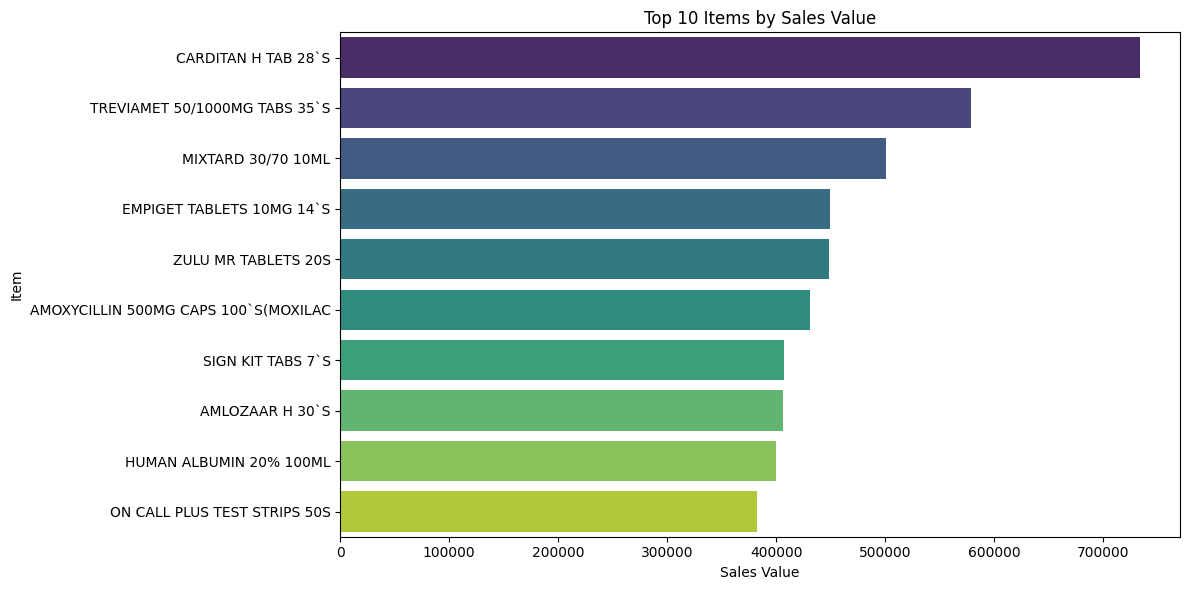

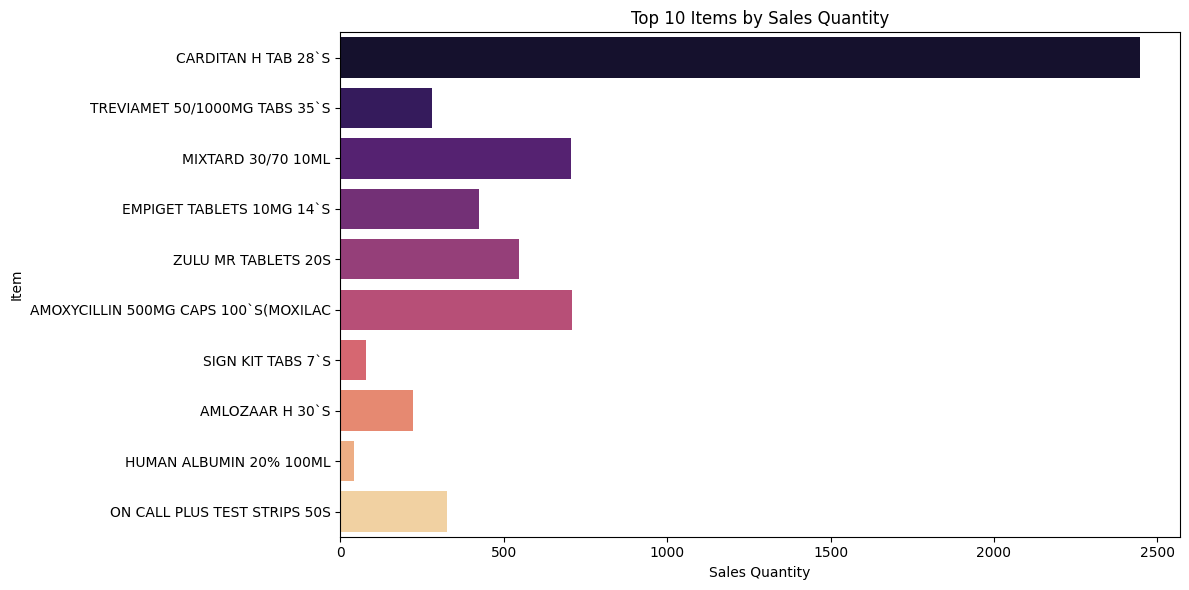

Visualized sales value and sales quantity for top 10 items.


In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x='sales_value', y='item', data=top_10_items_by_value, palette='viridis', hue='item', legend=False)
plt.title('Top 10 Items by Sales Value')
plt.xlabel('Sales Value')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='sales_qty', y='item', data=top_10_items_by_value, palette='magma', hue='item', legend=False)
plt.title('Top 10 Items by Sales Quantity')
plt.xlabel('Sales Quantity')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

print("Visualized sales value and sales quantity for top 10 items.")

##visualization of opening stock and closing stock



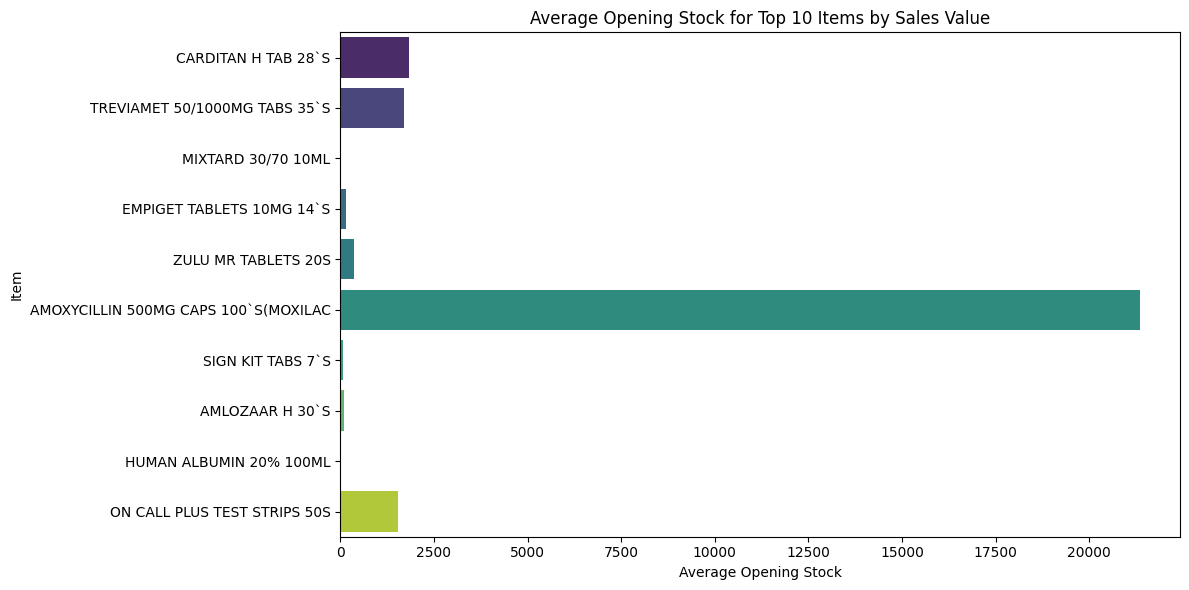

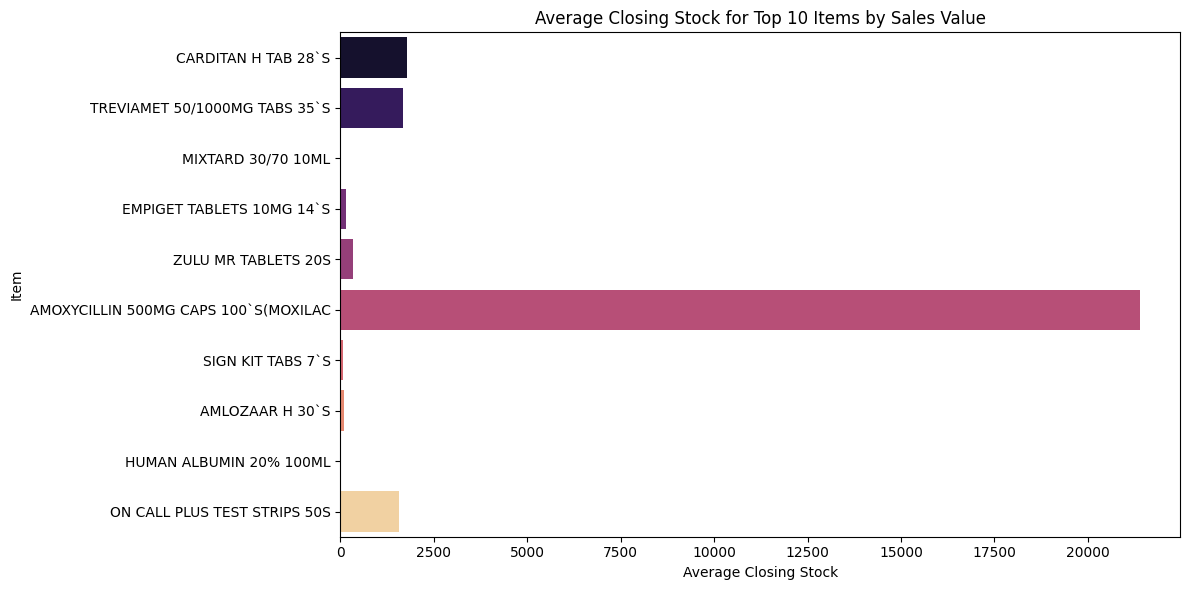

Visualized average opening and closing stock for top 10 items.


In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(x='op_stock_avg', y='item', data=top_10_items_by_value, palette='viridis', hue='item', legend=False)
plt.title('Average Opening Stock for Top 10 Items by Sales Value')
plt.xlabel('Average Opening Stock')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='cls_stock_avg', y='item', data=top_10_items_by_value, palette='magma', hue='item', legend=False)
plt.title('Average Closing Stock for Top 10 Items by Sales Value')
plt.xlabel('Average Closing Stock')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

print("Visualized average opening and closing stock for top 10 items.")

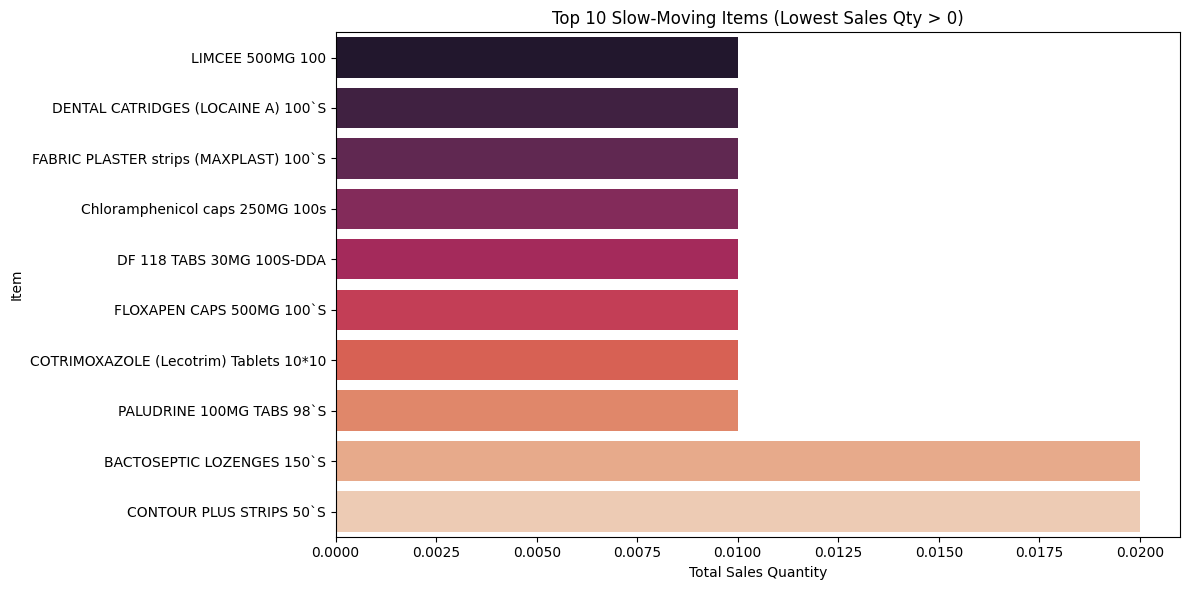

Identified slow-moving items based on low sales volume and stock availability.


,item,sales_qty,cls_stock_avg
2232,LIMCEE 500MG 100,0.01,3999.0
1158,DENTAL CATRIDGES (LOCAINE A) 100`S,0.01,499.0
1558,FABRIC PLASTER strips (MAXPLAST) 100`S,0.01,262.0
1084,Chloramphenicol caps 250MG 100s,0.01,199.0
1198,DF 118 TABS 30MG 100S-DDA,0.01,29.0
1629,FLOXAPEN CAPS 500MG 100`S,0.01,6.0
1014,COTRIMOXAZOLE (Lecotrim) Tablets 10*10,0.01,3.0
2951,PALUDRINE 100MG TABS 98`S,0.01,3.0
401,BACTOSEPTIC LOZENGES 150`S,0.02,199.0
989,CONTOUR PLUS STRIPS 50`S,0.02,48.0


In [18]:
# Identify slow-moving items: Low sales quantity but high closing stock
slow_moving_items = item_location_kpis[item_location_kpis['sales_qty'] > 0].sort_values(by=['sales_qty', 'cls_stock_avg'], ascending=[True, False]).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='sales_qty', y='item', data=slow_moving_items, palette='rocket', hue='item', legend=False)
plt.title('Top 10 Slow-Moving Items (Lowest Sales Qty > 0)')
plt.xlabel('Total Sales Quantity')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

print("Identified slow-moving items based on low sales volume and stock availability.")
display(slow_moving_items[['item', 'sales_qty', 'cls_stock_avg']])

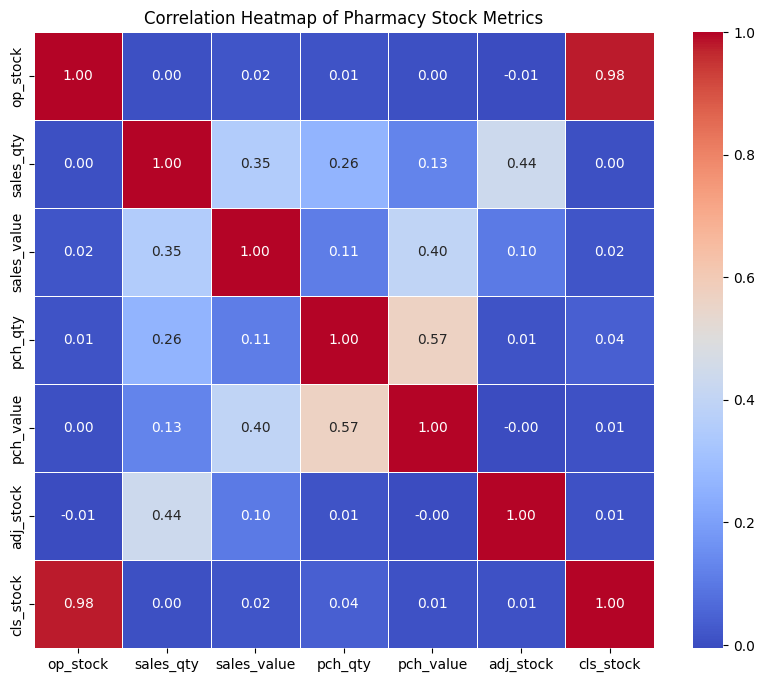

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numeric columns
corr_matrix = df[numeric_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Pharmacy Stock Metrics')
plt.show()

In [20]:
# @title 📊 Pharmacy Stock KPI Dashboard {display-mode: "form"}

import json
import pandas as pd
from IPython.display import HTML
from google.colab import output

# --- Error Handling Callback ---
def _report_js_error(message):
    print(f"JavaScript Error: {message}")

output.register_callback('report_js_error', _report_js_error)

# --- Data Preparation ---
# Using the top_10_items_by_value dataframe generated previously
dashboard_data = top_10_items_by_value.copy()

# Calculate dynamic KPIs for summary cards
total_val = dashboard_data['sales_value'].sum()
avg_qty = dashboard_data['sales_qty'].mean()
top_item = dashboard_data.iloc[0]['item']

kpi_data = {
    "total_value": f"{total_val:,.0f}",
    "avg_qty": f"{avg_qty:.2f}",
    "top_item": top_item,
    "item_count": len(dashboard_data)
}

# Prepare chart data
chart_json = dashboard_data.to_json(orient='records')

# --- Dashboard HTML/CSS/JS ---
html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; color: #333; }
        .dashboard-container { display: grid; grid-template-columns: repeat(4, 1fr); grid-gap: 20px; }

        .kpi-card { background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); text-align: center; }
        .kpi-card h3 { margin: 0; color: #666; font-size: 0.9rem; text-transform: uppercase; }
        .kpi-card p { margin: 10px 0 0; font-size: 1.8rem; font-weight: bold; color: #2c3e50; }

        .chart-section { grid-column: span 2; background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); display: flex; flex-direction: column; min-height: 400px; }
        .chart-wide { grid-column: span 4; }
        .chart-header { font-weight: bold; margin-bottom: 15px; font-size: 1.1rem; border-bottom: 1px solid #eee; padding-bottom: 10px; }

        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 0; width: 100%; }

        .table-container { grid-column: span 4; background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); overflow-x: auto; }
        table { width: 100%; border-collapse: collapse; margin-top: 10px; }
        th { text-align: left; background: #f8f9fa; padding: 12px; border-bottom: 2px solid #eee; }
        td { padding: 12px; border-bottom: 1px solid #eee; }
        tr:hover { background-color: #f1f1f1; }
    </style>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
</head>
<body>
    <div class="dashboard-container">
        <!-- KPI Cards -->
        <div class="kpi-card"><h3>Total Sales Value</h3><p>KSh KPI_TOTAL_VAL</p></div>
        <div class="kpi-card"><h3>Avg Sales Qty</h3><p>KPI_AVG_QTY</p></div>
        <div class="kpi-card"><h3>Top Performer</h3><p style="font-size: 1rem;">KPI_TOP_ITEM</p></div>
        <div class="kpi-card"><h3>Items Tracked</h3><p>KPI_COUNT</p></div>

        <!-- Charts -->
        <div class="chart-section">
            <div class="chart-header">Sales Value vs. Quantity</div>
            <div class="canvas-wrapper"><canvas id="valueQtyChart"></canvas></div>
        </div>

        <div class="chart-section">
            <div class="chart-header">Inventory: Opening vs. Closing Stock</div>
            <div class="canvas-wrapper"><canvas id="stockChart"></canvas></div>
        </div>

        <div class="chart-section chart-wide">
            <div class="chart-header">Performance Overview Table</div>
            <div class="table-container" id="dataTable"></div>
        </div>
    </div>

    <script>
        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };

        const rawData = DATA_PLACEHOLDER;

        function initCharts() {
            const labels = rawData.map(d => d.item.length > 20 ? d.item.substring(0,20) + '...' : d.item);

            // Chart 1: Value vs Quantity
            new Chart(document.getElementById('valueQtyChart'), {
                type: 'bar',
                data: {
                    labels: labels,
                    datasets: [{
                        label: 'Sales Value',
                        data: rawData.map(d => d.sales_value),
                        backgroundColor: 'rgba(54, 162, 235, 0.7)',
                        yAxisID: 'y'
                    }, {
                        label: 'Sales Qty',
                        data: rawData.map(d => d.sales_qty),
                        type: 'line',
                        borderColor: '#ff6384',
                        borderWidth: 3,
                        fill: false,
                        yAxisID: 'y1'
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    scales: {
                        y: { type: 'linear', position: 'left', title: { display: true, text: 'Value' } },
                        y1: { type: 'linear', position: 'right', grid: { drawOnChartArea: false }, title: { display: true, text: 'Quantity' } }
                    }
                }
            });

            // Chart 2: Stock Comparison
            new Chart(document.getElementById('stockChart'), {
                type: 'bar',
                data: {
                    labels: labels,
                    datasets: [{
                        label: 'Avg Opening Stock',
                        data: rawData.map(d => d.op_stock_avg),
                        backgroundColor: '#4bc0c0'
                    }, {
                        label: 'Avg Closing Stock',
                        data: rawData.map(d => d.cls_stock_avg),
                        backgroundColor: '#ffce56'
                    }]
                },
                options: {
                    responsive: true,
                    maintainAspectRatio: false,
                    indexAxis: 'y'
                }
            });

            // Table
            let tableHtml = '<table><thead><tr><th>Item</th><th>Sales Value</th><th>Sales Qty</th><th>Cls Stock</th></tr></thead><tbody>';
            rawData.forEach(row => {
                tableHtml += `<tr><td>${row.item}</td><td>${row.sales_value.toLocaleString()}</td><td>${row.sales_qty.toFixed(2)}</td><td>${row.cls_stock_avg.toFixed(0)}</td></tr>`;
            });
            tableHtml += '</tbody></table>';
            document.getElementById('dataTable').innerHTML = tableHtml;
        }

        initCharts();
    </script>
</body>
</html>
"""

# Injecting Data
final_html = html_template.replace('DATA_PLACEHOLDER', chart_json) \
                          .replace('KPI_TOTAL_VAL', kpi_data['total_value']) \
                          .replace('KPI_AVG_QTY', kpi_data['avg_qty']) \
                          .replace('KPI_TOP_ITEM', kpi_data['top_item']) \
                          .replace('KPI_COUNT', str(kpi_data['item_count']))

display(HTML(final_html))

## Prepare Data for Time-Series Forecasting

### Subtask:
Aggregate the data to a suitable time granularity (e.g., monthly) for sales forecasting, ensuring that each item and location has a complete time series of sales and stock-related metrics.


In [21]:
df_indexed = df.set_index('period_start')

ts_data = df_indexed.groupby(['item', 'location']).resample('MS').agg(
    sales_qty=('sales_qty', 'sum'),
    sales_value=('sales_value', 'sum'),
    cls_stock=('cls_stock', 'last')
).reset_index()

ts_data = ts_data.fillna({'sales_qty': 0, 'sales_value': 0, 'cls_stock': 0})

print("Prepared time-series data:")
print(ts_data.head())
print(ts_data.info())

Prepared time-series data:
                   item  location period_start  sales_qty  sales_value  \
0  (ANTACID)ALLUCID 4`S  PHARMACY   2023-02-01       6.25        790.0   
1  (ANTACID)ALLUCID 4`S  PHARMACY   2023-03-01       3.50        170.0   
2  (ANTACID)ALLUCID 4`S  PHARMACY   2023-04-01       0.00          0.0   
3  (ANTACID)ALLUCID 4`S  PHARMACY   2023-05-01       1.00        150.0   
4  (ANTACID)ALLUCID 4`S  PHARMACY   2023-06-01       0.00          0.0   

   cls_stock  
0       14.0  
1        0.0  
2        0.0  
3       76.0  
4        0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118358 entries, 0 to 118357
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   item          118358 non-null  object        
 1   location      118358 non-null  object        
 2   period_start  118358 non-null  datetime64[ns]
 3   sales_qty     118358 non-null  float64       
 4   sales_value   118

## Feature Engineering

**Reasoning**:
To enhance the predictive power of our models, I will create several new features from the `period_start` column and `sales_qty`. These features will include:

1.  **Time-based features**: Extracting year, month, day, day of week, day of year, and week of year from `period_start` will help capture seasonal and calendar effects.
2.  **Lag features**: Past `sales_qty` values (e.g., from 1, 2, and 3 months ago) can provide important information about the temporal dependency of sales.
3.  **Rolling window features**: Moving averages and standard deviations of `sales_qty` over different periods (e.g., 3-month and 6-month windows) can help smooth out noise and highlight underlying trends.

In [22]:
# Create time-based features
ts_data['year'] = ts_data['period_start'].dt.year
ts_data['month'] = ts_data['period_start'].dt.month
ts_data['day'] = ts_data['period_start'].dt.day
ts_data['dayofweek'] = ts_data['period_start'].dt.dayofweek
ts_data['dayofyear'] = ts_data['period_start'].dt.dayofyear
ts_data['weekofyear'] = ts_data['period_start'].dt.isocalendar().week.astype(int)

# Sort data for correct lag and rolling calculations
ts_data = ts_data.sort_values(by=['item', 'location', 'period_start']).reset_index(drop=True)

# Create lag features for sales_qty (1, 2, 3 months lag)
ts_data['sales_qty_lag1'] = ts_data.groupby(['item', 'location'])['sales_qty'].shift(1)
ts_data['sales_qty_lag2'] = ts_data.groupby(['item', 'location'])['sales_qty'].shift(2)
ts_data['sales_qty_lag3'] = ts_data.groupby(['item', 'location'])['sales_qty'].shift(3)

# Create rolling window features for sales_qty (3-month and 6-month rolling mean)
ts_data['sales_qty_roll_mean3'] = ts_data.groupby(['item', 'location'])['sales_qty'].transform(lambda x: x.rolling(window=3, min_periods=1).mean().shift(1))
ts_data['sales_qty_roll_mean6'] = ts_data.groupby(['item', 'location'])['sales_qty'].transform(lambda x: x.rolling(window=6, min_periods=1).mean().shift(1))

# Fill any NaN values created by lag and rolling features (e.g., at the beginning of each series)
ts_data = ts_data.fillna(0)

print("Feature engineering complete. Displaying head and info of the updated DataFrame:")
display(ts_data.head())
display(ts_data.info())

Feature engineering complete. Displaying head and info of the updated DataFrame:


,item,location,period_start,sales_qty,sales_value,cls_stock,year,month,day,dayofweek,dayofyear,weekofyear,sales_qty_lag1,sales_qty_lag2,sales_qty_lag3,sales_qty_roll_mean3,sales_qty_roll_mean6
0,(ANTACID)ALLUCID 4`S,PHARMACY,2023-02-01,6.25,790.0,14.0,2023,2,1,2,32,5,0.00,0.00,0.00,0.000,0.0000
1,(ANTACID)ALLUCID 4`S,PHARMACY,2023-03-01,3.50,170.0,0.0,2023,3,1,2,60,9,6.25,0.00,0.00,6.250,6.2500
2,(ANTACID)ALLUCID 4`S,PHARMACY,2023-04-01,0.00,0.0,0.0,2023,4,1,5,91,13,3.50,6.25,0.00,4.875,4.8750
3,(ANTACID)ALLUCID 4`S,PHARMACY,2023-05-01,1.00,150.0,76.0,2023,5,1,0,121,18,0.00,3.50,6.25,3.250,3.2500
4,(ANTACID)ALLUCID 4`S,PHARMACY,2023-06-01,0.00,0.0,0.0,2023,6,1,3,152,22,1.00,0.00,3.50,1.500,2.6875


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118358 entries, 0 to 118357
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   item                  118358 non-null  object        
 1   location              118358 non-null  object        
 2   period_start          118358 non-null  datetime64[ns]
 3   sales_qty             118358 non-null  float64       
 4   sales_value           118358 non-null  float64       
 5   cls_stock             118358 non-null  float64       
 6   year                  118358 non-null  int32         
 7   month                 118358 non-null  int32         
 8   day                   118358 non-null  int32         
 9   dayofweek             118358 non-null  int32         
 10  dayofyear             118358 non-null  int32         
 11  weekofyear            118358 non-null  int64         
 12  sales_qty_lag1        118358 non-null  float64       
 13 

None

## Prepare Data for Modeling and Simple Linear Regression

**Reasoning**:
Before training any model, I need to define the features (`X`) and the target variable (`y`). For time series forecasting, the target is usually the future value of the series, which in our case is `sales_qty`. The features will include the engineered time-based, lag, and rolling mean features. It's important to exclude the original `sales_qty`, `sales_value`, `cls_stock`, `item`, `location`, and `period_start` columns from the features, as they are either the target, not directly used as features, or are implicitly captured by other features.

In [23]:
#using time series split
from sklearn.model_selection import TimeSeriesSplit

# Initialize TimeSeriesSplit for time-aware cross-validation
# n_splits=5 provides 5 consecutive training/validation folds respecting chronological order
tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit initialized successfully.")

TimeSeriesSplit initialized successfully.


In [24]:
# from sklearn.model_selection import TimeSeriesSplit

# # Initialize TimeSeriesSplit
# tscv = TimeSeriesSplit(n_splits=5)

# # Example using TimeSeriesSplit with Random Forest
# rf_rmses = []
# rf_maes = []
# rf_r2s = []

# for train_index, test_index in tscv.split(X):
#     X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
#     y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

#     # Train model
#     rf_model.fit(X_train_cv, y_train_cv)
#     preds = rf_model.predict(X_test_cv)

#     # Evaluate fold
#     rf_rmses.append(np.sqrt(mean_squared_error(y_test_cv, preds)))
#     rf_maes.append(mean_absolute_error(y_test_cv, preds))
#     rf_r2s.append(r2_score(y_test_cv, preds))

# print(f"CV Mean RMSE: {np.mean(rf_rmses):.2f}")
# print(f"CV Mean R2: {np.mean(rf_r2s):.4f}")

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import numpy as np

# Define features (X) and target (y)
features = ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear',
            'sales_qty_lag1', 'sales_qty_lag2', 'sales_qty_lag3',
            'sales_qty_roll_mean3', 'sales_qty_roll_mean6']

X = ts_data[features]
y = ts_data['sales_qty']

# Split data into training and testing sets based on time
split_index = int(len(ts_data) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
linear_predictions = linear_model.predict(X_test)

# Evaluate the model using regression metrics
lm_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
lm_mae = mean_absolute_error(y_test, linear_predictions)
lm_r2 = r2_score(y_test, linear_predictions)
lm_evs = explained_variance_score(y_test, linear_predictions)


print(f"\n--- Simple Linear Regression Model Performance ---")
print(f"Root Mean Squared Error (RMSE): {lm_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {lm_mae:.2f}")
print(f"R-squared (R2 Score): {lm_r2:.4f}")
print(f"Explained Variance Score: {lm_evs:.4f}")

# Note: ROC AUC is for classification. For regression, R2 and EVS are the standard statistical measures.

# Store results for comparison later
model_results = {'Linear Regression': {'RMSE': lm_rmse, 'MAE': lm_mae, 'R2': lm_r2}}

print("\nLinear Regression model trained and evaluated with extended regression metrics.")

Training set size: 94686 samples
Testing set size: 23672 samples

--- Simple Linear Regression Model Performance ---
Root Mean Squared Error (RMSE): 4.05
Mean Absolute Error (MAE): 1.35
R-squared (R2 Score): 0.4586
Explained Variance Score: 0.4587

Linear Regression model trained and evaluated with extended regression metrics.


## Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# Using n_estimators=100 as a reasonable default for demonstration,
# but this can be tuned for better performance.
# random_state for reproducibility.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
rf_evs = explained_variance_score(y_test, rf_predictions)

print(f"\n--- Random Forest Model Performance ---")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"R-squared (R2 Score): {rf_r2:.4f}")
print(f"Explained Variance Score: {rf_evs:.4f}")

# Store results for comparison later
# model_results['Random Forest'] = {'RMSE': rf_rmse, 'MAE': rf_mae}
model_results['Random Forest'] = {'RMSE': rf_rmse, 'MAE': rf_mae, 'R2': rf_r2}

print("\nRandom Forest model trained and evaluated.")


--- Random Forest Model Performance ---
Root Mean Squared Error (RMSE): 4.92
Mean Absolute Error (MAE): 1.28
R-squared (R2 Score): 0.2034
Explained Variance Score: 0.2043

Random Forest model trained and evaluated.


In [27]:
# # 1. Feature Engineering: Adding interaction and ratio features
# ts_data['stock_sales_ratio'] = ts_data['cls_stock'] / (ts_data['sales_qty_lag1'] + 1)
# ts_data['rolling_std_3'] = ts_data.groupby(['item', 'location'])['sales_qty'].transform(lambda x: x.rolling(window=3, min_periods=1).std().shift(1)).fillna(0)

# # 2. Hyperparameter Tuning using RandomizedSearchCV for better generalization
# from sklearn.model_selection import RandomizedSearchCV

# param_distributions = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1)
# random_search = RandomizedSearchCV(estimator=rf_tuned, param_distributions=param_distributions,
#                                    n_iter=5, cv=3, scoring='r2', random_state=42, n_jobs=-1)
# random_search.fit(X_train, y_train)

# best_rf = random_search.best_estimator_
# print("Best Parameters:", random_search.best_params_)

## XGBoost Model

In [28]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor model
# Using default parameters for now, but these can be tuned for better performance.
# random_state for reproducibility.
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test)

# Evaluate the model
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)
xgb_evs = explained_variance_score(y_test, xgb_predictions)

print(f"\n--- XGBoost Model Performance ---")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {xgb_mae:.2f}")
print(f"R-squared (R2 Score): {xgb_r2:.4f}")
print(f"Explained Variance Score: {xgb_evs:.4f}")

# Store results for comparison later
model_results['XGBoost'] = {'RMSE': xgb_rmse, 'MAE': xgb_mae, 'R2': xgb_r2}

print("\nXGBoost model trained and evaluated.")

print("\n--- Model Comparison ---")
for model_name, metrics in model_results.items():
    print(f"{model_name}: RMSE = {metrics['RMSE']:.2f}, MAE = {metrics['MAE']:.2f}")


--- XGBoost Model Performance ---
Root Mean Squared Error (RMSE): 5.00
Mean Absolute Error (MAE): 1.26
R-squared (R2 Score): 0.1774
Explained Variance Score: 0.1778

XGBoost model trained and evaluated.

--- Model Comparison ---
Linear Regression: RMSE = 4.05, MAE = 1.35
Random Forest: RMSE = 4.92, MAE = 1.28
XGBoost: RMSE = 5.00, MAE = 1.26


In [29]:
comparison_df = pd.DataFrame(model_results).T
print("\n--- Model Performance Comparison Table ---")
print(comparison_df.round(2).to_markdown(numalign="left", stralign="left"))


--- Model Performance Comparison Table ---
|                   | RMSE   | MAE   | R2   |
|:------------------|:-------|:------|:-----|
| Linear Regression | 4.05   | 1.35  | 0.46 |
| Random Forest     | 4.92   | 1.28  | 0.2  |
| XGBoost           | 5      | 1.26  | 0.18 |


#Save the model for use in our system

In [30]:
import joblib

# Save the trained Random Forest model to disk
joblib.dump(rf_model, "/content/drive/MyDrive/ENGAGEMary_Diana/Engage_Pharm_Data/models/pharm_rf_model.pkl")

# Save a clean sample of your preprocessed data so the app can lookup items/locations
ts_data.to_csv("/content/drive/MyDrive/ENGAGEMary_Diana/Engage_Pharm_Data/models/streamlit_pharm_data.csv", index=False)

print("Model and data successfully saved for deployment!")

Model and data successfully saved for deployment!


##Step 1: Add a Code Cell to Install Dependencies

In [31]:
# !pip install streamlit pyngrok -q
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 66.5 MB/s eta 0:00:00


##Step 2: Create and Run app.py via Colab

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os

# Page configuration
st.set_page_config(page_title="PharmStock AI Forecaster", layout="wide")

st.title("💊 PharmStock AI: Sales Forecasting Dashboard")
st.write("Predict future sales quantities using our trained Random Forest model.")

# Load saved model and data from your Google Drive path
@st.cache_resource
def load_assets():
    model_path = "/content/drive/MyDrive/ENGAGEMary_Diana/Engage_Pharm_Data/models/pharm_rf_model.pkl"
    data_path = "/content/drive/MyDrive/ENGAGEMary_Diana/Engage_Pharm_Data/models/streamlit_pharm_data.csv"

    model = joblib.load(model_path)
    data = pd.read_csv(data_path)
    return model, data

model, df = load_assets()

# Sidebar inputs for user selection
st.sidebar.header("Forecast Parameters")
selected_location = st.sidebar.selectbox("Select Location", df['location'].unique())
filtered_items = df[df['location'] == selected_location]['item'].unique()
selected_item = st.sidebar.selectbox("Select Item", filtered_items)

# Pull recent historical stats for this item to set smart defaults
item_subset = df[(df['item'] == selected_item) & (df['location'] == selected_location)]
recent_sales = item_subset['sales_qty'].iloc[-1] if not item_subset.empty else 1.0

st.subheader(f"Forecasting for: `{selected_item}` at `{selected_location}`")

# Input features configuration matching your training schema
col1, col2 = st.columns(2)

with col1:
    year = st.number_input("Year", min_value=2023, max_value=2030, value=2026)
    month = st.slider("Month", min_value=1, max_value=12, value=9)
    day = st.number_input("Day", min_value=1, max_value=31, value=1)
    dayofweek = st.slider("Day of Week (0=Mon, 6=Sun)", 0, 6, 1)

with col2:
    sales_qty_lag1 = st.number_input("Sales Qty (1 Month Ago)", value=float(recent_sales))
    sales_qty_lag2 = st.number_input("Sales Qty (2 Months Ago)", value=float(recent_sales))
    sales_qty_lag3 = st.number_input("Sales Qty (3 Months Ago)", value=float(recent_sales))
    sales_qty_roll_mean3 = st.number_input("3-Month Rolling Mean Sales", value=float(recent_sales))
    sales_qty_roll_mean6 = st.number_input("6-Month Rolling Mean Sales", value=float(recent_sales))

# Additional time-based feature calculation
dayofyear = pd.Timestamp(f"{year}-{month:02d}-{day:02d}").dayofyear
weekofyear = pd.Timestamp(f"{year}-{month:02d}-{day:02d}").isocalendar().week

# Construct feature array in the exact order the model expects
input_features = np.array([[
    year, month, day, dayofweek, dayofyear, weekofyear,
    sales_qty_lag1, sales_qty_lag2, sales_qty_lag3,
    sales_qty_roll_mean3, sales_qty_roll_mean6
]])

# Prediction button
if st.button("Generate Prediction", type="primary"):
    prediction = model.predict(input_features)[0]

    st.success(f"### Predicted Sales Quantity: {prediction:.2f} units")

    # Simple stockout warning heuristic
    if prediction > sales_qty_lag1:
        st.warning("⚠️ **High Demand Alert:** Predicted sales exceed last month's quantity. Consider increasing reorder quantities.")
    else:
        st.info("ℹ️ **Stable Demand:** Sales projected to remain steady or decrease.")

# Copy the generated app.py into your Google Drive folder
!cp app.py /content/drive/MyDrive/ENGAGEMary_Diana/Engage_Pharm_Data/models/app.py
print("app.py successfully corrected and saved to Google Drive!")

##Step 3: Launch Streamlit with LocalTunnel

In [ ]:
# Run streamlit in the background
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-09-18 07:05:25.413 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.243.147.54:8501



In [ ]:
from pyngrok import ngrok

# Authenticate if you have an ngrok token (optional for testing, but helps avoid connection walls)
# ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN")

# Terminate any existing tunnels
ngrok.kill()

# Open a tunnel to the streamlit port (8501)
public_url = ngrok.connect(8501)
print(f"🚀 Your live Streamlit App is available at: {public_url}")

# Run streamlit in the background
!streamlit run app.py &

##Model deployment in Streamlit

## Propose Inventory Optimization Strategy

### Subtask:
Develop a strategy to minimize overstocking and stockouts based on the sales forecasts, incorporating considerations such as lead times, safety stock, and demand variability.

### Conceptual Framework for Inventory Optimization

Our sales forecasting models (Linear Regression, Random Forest, XGBoost) provide predictions for future `sales_qty`. These forecasts are fundamental for an effective inventory strategy. Here's how we can conceptualize the optimization:

1.  **Demand Forecasting**: The core input is the predicted `sales_qty` for each item and location for future periods. We'll use the predictions from the chosen best-performing model (or an ensemble of models) as our demand forecast.

2.  **Reorder Point (ROP) Calculation**: The ROP is the inventory level at which a new order should be placed. It's calculated to cover demand during the lead time (time between placing an order and receiving it) and includes a safety stock to guard against demand variability or delays.  
    *   `ROP = (Average Daily Demand * Lead Time) + Safety Stock`

3.  **Safety Stock Calculation**: Safety stock is extra inventory held to prevent stockouts due to uncertainties in demand or lead time. It can be calculated based on desired service level and variability of demand/lead time.  
    *   `Safety Stock = Z-score (for desired service level) * Standard Deviation of Demand During Lead Time`

4.  **Economic Order Quantity (EOQ)**: While not directly derived from forecasts, EOQ helps determine the optimal order size to minimize total inventory costs (holding costs and ordering costs). This is relevant for *how much* to order when the ROP is hit.

5.  **Overstock/Understock Identification**: By comparing current inventory levels with the calculated ROP and expected demand, we can proactively identify potential overstock (if current stock significantly exceeds ROP + future demand) or understock (if current stock is below ROP).

6.  **Item Segmentation**: Different items might require different inventory strategies. High-value, fast-moving items might need more precise forecasting and smaller safety stocks (due to higher holding costs), while slow-moving, low-cost items might tolerate larger safety stocks or less frequent ordering.

**Next steps in implementing this strategy could involve:**
*   Defining and collecting data for `Lead Time` for each item.
*   Specifying a desired `Service Level` (e.g., 95%, 99%).
*   Calculating the standard deviation of `sales_qty` to estimate demand variability.
*   Developing a system to continuously monitor current stock levels against calculated reorder points.
*   Integrating this with procurement systems to trigger orders automatically or semi-automatically.